In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Chargement du fichier
df = pd.read_csv(r'C:\Users\meria\Downloads\mlProject\prepared_data.csv')

print(f"Dataset chargé avec succès !")
print(f"Shape: {df.shape}")
print(f"Colonnes: {list(df.columns)}")
print("\nAperçu des 5 premières lignes :")
print(df.head())

Dataset chargé avec succès !
Shape: (10000, 29)
Colonnes: ['Job_Title', 'Median_Salary_USD', 'Experience_Required_Years', 'Remote_Work_Ratio_%', 'Automation_Risk_%', 'Gender_Diversity_%', 'Job_Growth_Rate_%', 'Growth_Category', 'Job_Value_Index', 'Vulnerability_Index', 'Required_Education_num', 'AI_Impact_Level_num', 'Job_Status_num', 'Industry_education', 'Industry_entertainment', 'Industry_finance', 'Industry_healthcare', 'Industry_it', 'Industry_manufacturing', 'Industry_retail', 'Industry_transportation', 'Location_australia', 'Location_brazil', 'Location_canada', 'Location_china', 'Location_germany', 'Location_india', 'Location_uk', 'Location_usa']

Aperçu des 5 premières lignes :
                            Job_Title  Median_Salary_USD  \
0  research scientist (life sciences)           0.900512   
1                        tefl teacher           0.832271   
2           editor, magazine features           0.158126   
3                journalist, magazine           1.442231   
4    

PREPARATION DES DONNEES POUR XGBOOST (BO1: Classification du Growth Category)
Mapping Growth Category: {'decline': np.int64(0), 'high_growth': np.int64(1), 'stable': np.int64(2)}
Features used for classification: ['Median_Salary_USD', 'Experience_Required_Years', 'Remote_Work_Ratio_%', 'Automation_Risk_%', 'Gender_Diversity_%', 'Job_Growth_Rate_%', 'Job_Value_Index', 'Vulnerability_Index', 'Required_Education_num', 'AI_Impact_Level_num', 'Industry_education', 'Industry_entertainment', 'Industry_finance', 'Industry_healthcare', 'Industry_it', 'Industry_manufacturing', 'Industry_retail', 'Industry_transportation', 'Location_australia', 'Location_brazil', 'Location_canada', 'Location_china', 'Location_germany', 'Location_india', 'Location_uk', 'Location_usa']
Target variable: Growth_Category
Shape of X: (10000, 26)
Shape of y: (10000,)

ENTRAINEMENT DU MODÈLE XGBOOST
Modèle XGBoost entraîné avec succès!

ÉVALUATION DU MODÈLE
Accuracy: 0.9965

Classification Report:
              precision

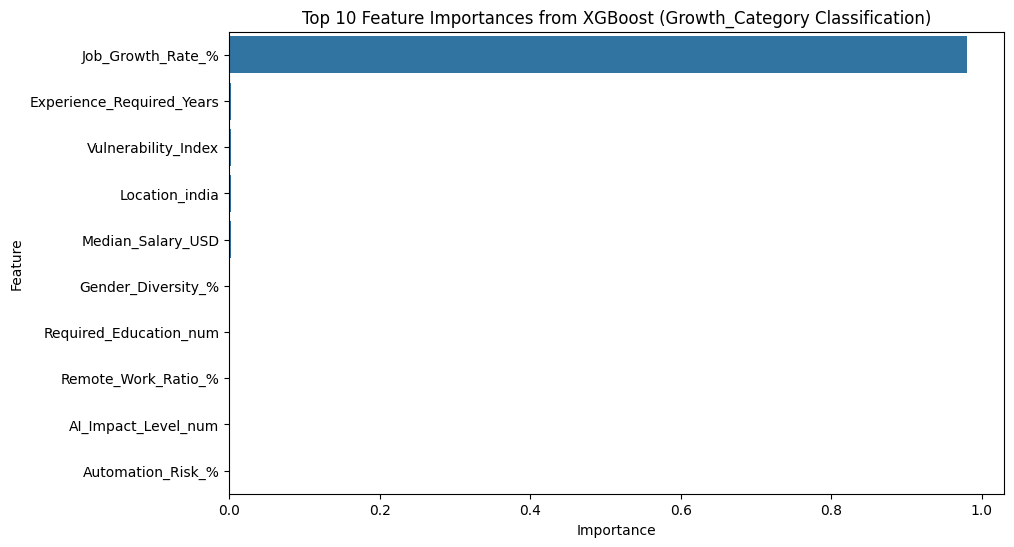

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import numpy as np # Import numpy

le_growth_category = LabelEncoder()
df['Growth_Category_encoded'] = le_growth_category.fit_transform(df['Growth_Category'])

print(f"Mapping Growth Category: {dict(zip(le_growth_category.classes_, le_growth_category.transform(le_growth_category.classes_)))}")

# Features are all columns except 'Job_Title', 'Growth_Category', and 'Job_Status_num'
# Also exclude 'Growth_Category_encoded' from features to avoid data leakage
features_bo1 = [col for col in df.columns if col not in ['Job_Title', 'Growth_Category', 'Job_Status_num', 'Growth_Category_encoded']]

# Define X (features) and y (target)
X = df[features_bo1]
y = df['Growth_Category_encoded']

print(f"Features used for classification: {features_bo1}")
print(f"Target variable: Growth_Category")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n" + "="*60)
print("ENTRAINEMENT DU MODÈLE XGBOOST")
print("="*60)

# Initialize and train the XGBoost Classifier
# Use 'objective="multi:softmax"' for multi-class classification and 'num_class' for the number of classes
model = xgb.XGBClassifier(objective='multi:softmax', num_class=len(le_growth_category.classes_), eval_metric='mlogloss', use_label_encoder=False, random_state=42)
model.fit(X_train, y_train)

print("Modèle XGBoost entraîné avec succès!")

# --- ÉVALUATION DU MODÈLE ---
print("\n" + "="*60)
print("ÉVALUATION DU MODÈLE")
print("="*60)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_growth_category.classes_))

# Feature Importance
print("\n" + "="*60)
print("IMPORTANCE DES FEATURES")
print("="*60)

# Get feature importance from the trained model
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importances.head(10).to_string(index=False))

# Visualize Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(10))
plt.title('Top 10 Feature Importances from XGBoost (Growth_Category Classification)')
plt.show()

### K-Fold Cross-Validation for the Initial XGBoost Model

In [ ]:
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
import numpy as np

# Re-initialize the base XGBoost model for BO1 (Growth_Category classification)
# Use 'objective="multi:softmax"' for multi-class classification and 'num_class'
initial_model_bo1 = xgb.XGBClassifier(objective='multi:softmax', num_class=len(le_growth_category.classes_), eval_metric='mlogloss', use_label_encoder=False, random_state=42)

# Define K-Fold Cross-Validation
num_folds = 5 # You can change the number of folds
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

cv_scores = []

print(f"Performing {num_folds}-Fold Cross-Validation...")

# Use X and y (which are currently set for Growth_Category classification) for cross-validation
for fold, (train_index, val_index) in enumerate(kf.split(X, y)):
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

    # Train the model on the training fold
    initial_model_bo1.fit(X_train_fold, y_train_fold)

    # Make predictions on the validation fold
    y_pred_fold = initial_model_bo1.predict(X_val_fold)

    # Calculate accuracy for this fold
    fold_accuracy = accuracy_score(y_val_fold, y_pred_fold)
    cv_scores.append(fold_accuracy)
    print(f"Fold {fold+1} Accuracy: {fold_accuracy:.4f}")

print(f"\nMean CV Accuracy: {np.mean(cv_scores):.4f}")
print(f"Std Dev CV Accuracy: {np.std(cv_scores):.4f}")

Performing 5-Fold Cross-Validation...
Fold 1 Accuracy: 0.9970
Fold 2 Accuracy: 0.9990
Fold 3 Accuracy: 0.9995
Fold 4 Accuracy: 0.9960
Fold 5 Accuracy: 0.9985

Mean CV Accuracy: 0.9980
Std Dev CV Accuracy: 0.0013


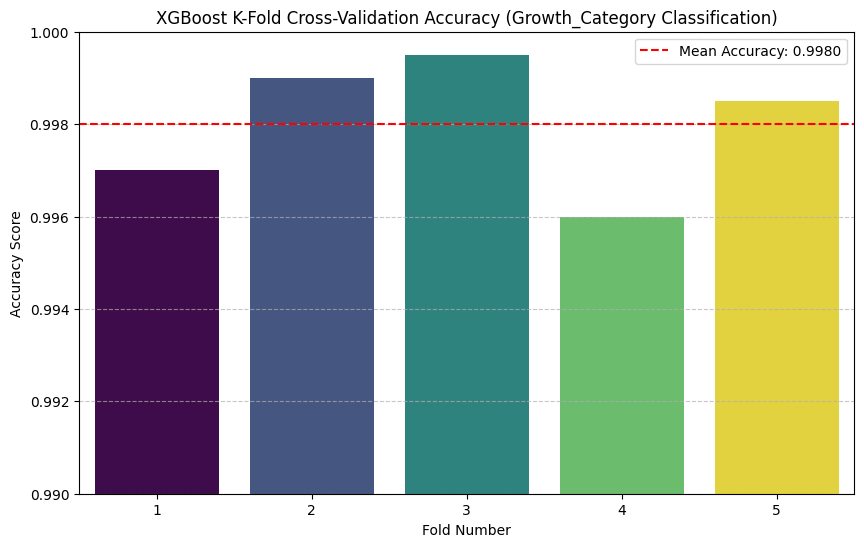

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Ensure numpy is imported for np.mean

# Create a DataFrame for plotting cross-validation scores
cv_results_df = pd.DataFrame({
    'Fold': range(1, num_folds + 1),
    'Accuracy': cv_scores
})
plt.figure(figsize=(10, 6))
sns.barplot(x='Fold', y='Accuracy', data=cv_results_df, palette='viridis', hue='Fold', legend=False)
plt.axhline(y=np.mean(cv_scores), color='r', linestyle='--', label=f'Mean Accuracy: {np.mean(cv_scores):.4f}')
plt.title('XGBoost K-Fold Cross-Validation Accuracy (Growth_Category Classification)')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy Score')
plt.ylim(0.99, 1.0) # Adjusted y-axis for better visualization of high scores for BO1
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##Implement Grid Search

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for XGBoost
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0]
}

# Initialize the XGBoost Classifier for multi-class classification (BO1: Growth_Category)
model_for_grid_search = xgb.XGBClassifier(
    objective='multi:softmax', # Changed to multi-class objective for Growth_Category
    num_class=len(le_growth_category.classes_), # Specify number of classes
    eval_metric='mlogloss',       # Changed to mlogloss for multi-class classification
    use_label_encoder=False,
    random_state=42
)

# Instantiate GridSearchCV
grid_search = GridSearchCV(
    estimator=model_for_grid_search,
    param_grid=param_grid,
    cv=3, # Using 3-fold cross-validation as an example
    scoring='accuracy',
    verbose=2,
    n_jobs=-1 # Use all available CPU cores
)

print("Starting Grid Search...")
# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("\nGrid Search completed!")

# Print the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: {:.4f}".format(grid_search.best_score_))

Starting Grid Search...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Grid Search completed!
Best parameters found:  {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 100, 'subsample': 1.0}
Best cross-validation accuracy: 0.9971


##Implement Random Search

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Define the parameter distribution for XGBoost
param_distributions = {
    'n_estimators': randint(50, 200), # Number of boosting rounds
    'max_depth': randint(3, 10),      # Maximum tree depth
    'learning_rate': uniform(0.01, 0.3), # Step size shrinkage to prevent overfitting
    'subsample': uniform(0.6, 0.4),   # Subsample ratio of the training instance
    'colsample_bytree': uniform(0.6, 0.4) # Subsample ratio of columns when constructing each tree
}

# Initialize the XGBoost Classifier for multi-class classification (BO1: Growth_Category)
model_for_random_search = xgb.XGBClassifier(
    objective='multi:softmax', # Changed to multi-class objective
    num_class=len(le_growth_category.classes_), # Specify number of classes
    eval_metric='mlogloss',       # Changed to mlogloss for multi-class classification
    use_label_encoder=False,
    random_state=42
)

# Instantiate RandomizedSearchCV
# n_iter controls the number of parameter settings that are sampled
random_search = RandomizedSearchCV(
    estimator=model_for_random_search,
    param_distributions=param_distributions,
    n_iter=50, # Sample 50 different parameter combinations
    cv=3,      # Using 3-fold cross-validation
    scoring='accuracy',
    verbose=2,
    random_state=42,
    n_jobs=-1  # Use all available CPU cores
)

print("Starting Random Search...")
# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

print("\nRandom Search completed!")

# Print the best parameters and best score
print("Best parameters found: ", random_search.best_params_)
print("Best cross-validation accuracy: {:.4f}".format(random_search.best_score_))

Starting Random Search...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

Random Search completed!
Best parameters found:  {'colsample_bytree': np.float64(0.6579579488364892), 'learning_rate': np.float64(0.1568358280832689), 'max_depth': 8, 'n_estimators': 117, 'subsample': np.float64(0.632341330533086)}
Best cross-validation accuracy: 0.9970


##Compare Search Results

In [ ]:
# Retrieve best parameters and score from Grid Search
best_params_grid = grid_search.best_params_
best_score_grid = grid_search.best_score_

# Retrieve best parameters and score from Random Search
best_params_random = random_search.best_params_
best_score_random = random_search.best_score_

print("\n============================================================")
print("COMPARISON OF HYPERPARAMETER SEARCH RESULTS")
print("============================================================")

print("\n--- Grid Search Results ---")
print(f"Best Parameters: {best_params_grid}")
print(f"Best Cross-Validation Accuracy: {best_score_grid:.4f}")

print("\n--- Random Search Results ---")
print(f"Best Parameters: {best_params_random}")
print(f"Best Cross-Validation Accuracy: {best_score_random:.4f}")

print("\n============================================================")
print("CONCLUSION")
print("============================================================")

if best_score_grid > best_score_random:
    print(f"Grid Search yielded a better model configuration with an accuracy of {best_score_grid:.4f}.")
    print(f"Optimal Parameters (Grid Search): {best_params_grid}")
elif best_score_random > best_score_grid:
    print(f"Random Search yielded a better model configuration with an accuracy of {best_score_random:.4f}.")
    print(f"Optimal Parameters (Random Search): {best_params_random}")
else:
    print(f"Both Grid Search and Random Search yielded the same best accuracy of {best_score_grid:.4f}.")
    print(f"Optimal Parameters (Grid Search): {best_params_grid}")
    print(f"Optimal Parameters (Random Search): {best_params_random}")


COMPARISON OF HYPERPARAMETER SEARCH RESULTS

--- Grid Search Results ---
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100, 'subsample': 1.0}
Best Cross-Validation Accuracy: 0.9970

--- Random Search Results ---
Best Parameters: {'colsample_bytree': np.float64(0.6579579488364892), 'learning_rate': np.float64(0.1568358280832689), 'max_depth': 8, 'n_estimators': 117, 'subsample': np.float64(0.632341330533086)}
Best Cross-Validation Accuracy: 0.9970

CONCLUSION
Grid Search yielded a better model configuration with an accuracy of 0.9970.
Optimal Parameters (Grid Search): {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100, 'subsample': 1.0}
